In [2]:
import re
from pathlib import Path
import pandas as pd

SIM_DIR = Path("sim_outputs")

records = []
for token_file in sorted(SIM_DIR.glob("*/token_usage.txt")):
    run_name = token_file.parent.name
    # extract num_agents suffix if present (e.g. run_..._2 -> 2)
    parts = run_name.rsplit("_", 1)
    num_agents = int(parts[-1]) if parts[-1].isdigit() and len(parts) > 1 else None

    text = token_file.read_text()

    # per-step rows
    for m in re.finditer(r"t=(\d+):\s+(\d+)\s+tokens", text):
        records.append({
            "run": run_name,
            "num_agents": num_agents,
            "t": int(m.group(1)),
            "step_tokens": int(m.group(2)),
        })

    # summary totals
    prompt_tok  = int(re.search(r"Total prompt tokens:\s+(\d+)", text).group(1))
    compl_tok   = int(re.search(r"Total completion tokens:\s+(\d+)", text).group(1))
    total_tok   = int(re.search(r"Total tokens:\s+(\d+)", text).group(1))
    total_calls = int(re.search(r"Total LLM calls:\s+(\d+)", text).group(1))

    for r in records:
        if r["run"] == run_name:
            r["total_prompt_tokens"]     = prompt_tok
            r["total_completion_tokens"] = compl_tok
            r["total_tokens"]            = total_tok
            r["total_llm_calls"]         = total_calls

df = pd.DataFrame(records)
print(f"{len(df)} rows from {df['run'].nunique()} runs")
df.head(15)

183 rows from 16 runs


,run,num_agents,t,step_tokens,total_prompt_tokens,total_completion_tokens,total_tokens,total_llm_calls
0,run_20260402_194812_2,2,0,1743,13148,1043,14191,18
1,run_20260402_194812_2,2,10,3307,13148,1043,14191,18
2,run_20260402_194812_2,2,12,732,13148,1043,14191,18
3,run_20260402_194812_2,2,14,724,13148,1043,14191,18
4,run_20260402_194812_2,2,16,736,13148,1043,14191,18
5,run_20260402_194812_2,2,18,746,13148,1043,14191,18
6,run_20260402_194812_2,2,19,750,13148,1043,14191,18
7,run_20260402_194812_2,2,20,3286,13148,1043,14191,18
8,run_20260402_194812_2,2,26,683,13148,1043,14191,18
9,run_20260402_194812_2,2,27,744,13148,1043,14191,18


/tmp/ipykernel_486748/2775635724.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  BLUE_CMAP = plt.cm.get_cmap("Blues")


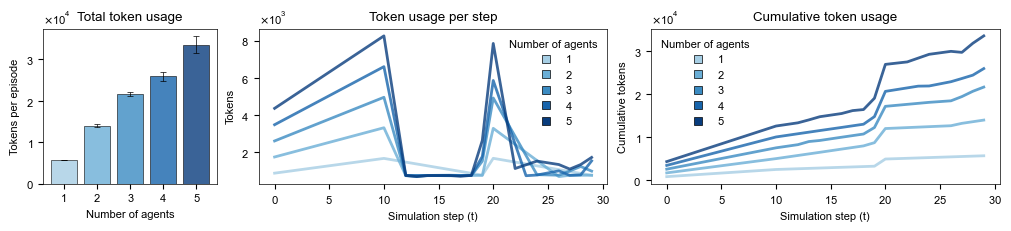

In [79]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patheffects as pe
import numpy as np

plt.rcParams.update({"font.family": "Arial", "font.size": 8,
                     "axes.formatter.use_mathtext": True,
                     "axes.linewidth": 0.5})

BLUE_CMAP = plt.cm.get_cmap("Blues")
agent_counts = sorted(df["num_agents"].dropna().unique().astype(int))
n_groups = len(agent_counts)
colors = {n: BLUE_CMAP(0.35 + 0.6 * i / max(n_groups - 1, 1))
          for i, n in enumerate(agent_counts)}

fig, axes = plt.subplots(1, 3, figsize=(10, 2.2),
                         gridspec_kw={"width_ratios": [1, 2, 2]},
                         constrained_layout=True)

# --- Panel 1: Total tokens per run, grouped by num_agents (bar + error) ---
ax = axes[0]
run_totals = df.groupby(["run", "num_agents"])["total_tokens"].first().reset_index()
stats = run_totals.groupby("num_agents")["total_tokens"].agg(["mean", "std"]).reindex(agent_counts)
bars = ax.bar(range(n_groups), stats["mean"], yerr=stats["std"], capsize=2,
              color=[colors[n] for n in agent_counts], edgecolor="black", linewidth=0.5, alpha=0.8,
              error_kw={"ecolor": "black", "linewidth": 0.5, "capthick": 0.5})
ax.set_xticks(range(n_groups))
ax.set_xticklabels(agent_counts)
ax.set_xlabel("Number of agents")
ax.set_ylabel("Tokens per episode")
ax.set_title("Total token usage")
ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

# --- Panel 2: Tokens per step (mean ± std across replicates) ---
ax = axes[1]
for n in agent_counts:
    sub = df[df["num_agents"] == n]
    agg = sub.groupby("t")["step_tokens"].mean().sort_index()
    ax.plot(agg.index, agg.values, color=colors[n], alpha=0.8, linewidth=2)
handles = [plt.Line2D([0], [0], color=colors[n], lw=3, label=f"{n}",
                      marker="s", markersize=6, markeredgecolor="black", markeredgewidth=0.5,
                      linestyle="None")
           for n in agent_counts]
ax.legend(handles=handles, fontsize=8, loc="upper right", frameon=False, title="Number of agents", title_fontsize=8)
ax.set_xlabel("Simulation step (t)")
ax.set_ylabel("Tokens")
ax.set_title("Token usage per step")
ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

# --- Panel 3: Cumulative tokens over time (mean across replicates) ---
ax = axes[2]
for n in agent_counts:
    sub = df[df["num_agents"] == n].sort_values(["run", "t"])
    sub = sub.assign(cum_tokens=sub.groupby("run")["step_tokens"].cumsum())
    agg = sub.groupby("t")["cum_tokens"].mean().sort_index()
    ax.plot(agg.index, agg.values, color=colors[n], alpha=0.8, linewidth=2)
handles = [plt.Line2D([0], [0], color=colors[n], lw=3, label=f"{n}",
                      marker="s", markersize=6, markeredgecolor="black", markeredgewidth=0.5,
                      linestyle="None")
           for n in agent_counts]
ax.legend(handles=handles, fontsize=8, loc="upper left", frameon=False, title="Number of agents", title_fontsize=8)
ax.set_xlabel("Simulation step (t)")
ax.set_ylabel("Cumulative tokens")
ax.set_title("Cumulative token usage")
ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

plt.savefig("sim_outputs/token_scalability.png", dpi=800, bbox_inches="tight",transparent=True)
plt.show()

In [85]:
import re
from pathlib import Path

SIM_DIR = Path("sim_outputs")

evac_records = []
for run_dir in sorted(SIM_DIR.iterdir()):
    if not run_dir.is_dir() or not run_dir.name.startswith("run_"):
        continue
    parts = run_dir.name.rsplit("_", 1)
    num_agents = int(parts[-1]) if parts[-1].isdigit() and len(parts) > 1 else None

    for traj_file in sorted(run_dir.glob("*/trajectory.txt")):
        agent_name = traj_file.parent.name
        text = traj_file.read_text()

        reached_park = False
        last_location = None
        for m in re.finditer(r"Observation:\s+At:(\S+)", text):
            loc = m.group(1)
            last_location = loc
            if loc == "Park":
                reached_park = True

        steps = re.findall(r"^Step (\d+)", text, re.MULTILINE)
        last_step = int(steps[-1]) if steps else None
        first_park_step = None
        if reached_park:
            for m in re.finditer(r"Step (\d+)\n(?:.*\n)*? Observation:\s+At:Park", text):
                first_park_step = int(m.group(1))
                break

        evac_records.append({
            "run": run_dir.name,
            "num_agents": num_agents,
            "agent": agent_name.replace("_", " "),
            "reached_park": reached_park,
            "first_park_step": first_park_step,
            "last_location": last_location,
            "last_step": last_step,
        })

evac_df = pd.DataFrame(evac_records)
print(f"{len(evac_df)} agent-trajectories from {evac_df['run'].nunique()} runs")
evac_df.head(10)

50 agent-trajectories from 16 runs


,run,num_agents,agent,reached_park,first_park_step,last_location,last_step
0,run_20260402_194812_2,2,Isabella Rodriguez,True,11.0,street,30
1,run_20260402_194812_2,2,Klaus Mueller,False,NaN,street,30
2,run_20260402_194916_3,3,Haruka Tanaka,True,11.0,Park,30
3,run_20260402_194916_3,3,Isabella Rodriguez,False,NaN,street,30
4,run_20260402_194916_3,3,Klaus Mueller,False,NaN,street,30
5,run_20260402_195112_3,3,Haruka Tanaka,True,11.0,Park,30
6,run_20260402_195112_3,3,Isabella Rodriguez,False,NaN,street,30
7,run_20260402_195112_3,3,Klaus Mueller,False,NaN,street,30
8,run_20260402_195429_3,3,Haruka Tanaka,True,11.0,Park,30
9,run_20260402_195429_3,3,Isabella Rodriguez,False,NaN,street,30


/tmp/ipykernel_486748/858769389.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  BLUE_CMAP = plt.cm.get_cmap("Blues")


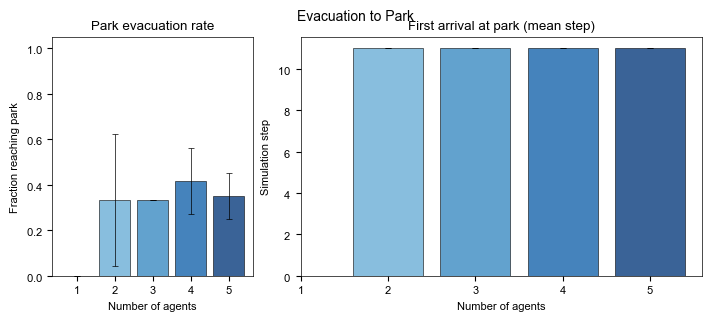

In [86]:
plt.rcParams.update({"font.family": "Arial", "font.size": 8,
                     "axes.formatter.use_mathtext": True,
                     "axes.linewidth": 0.5})

agent_counts = sorted(evac_df["num_agents"].dropna().unique().astype(int))
n_groups = len(agent_counts)
BLUE_CMAP = plt.cm.get_cmap("Blues")
colors = {n: BLUE_CMAP(0.35 + 0.6 * i / max(n_groups - 1, 1))
          for i, n in enumerate(agent_counts)}

fig, axes = plt.subplots(1, 2, figsize=(7, 3), constrained_layout=True,
                         gridspec_kw={"width_ratios": [1, 2]})

# --- Panel A: Fraction of agents reaching the park per num_agents ---
ax = axes[0]
rate = (evac_df.groupby(["run", "num_agents"])["reached_park"]
        .mean().reset_index()
        .groupby("num_agents")["reached_park"]
        .agg(["mean", "std"]).reindex(agent_counts))
bars = ax.bar(range(n_groups), rate["mean"], yerr=rate["std"], capsize=2,
              color=[colors[n] for n in agent_counts], edgecolor="black", linewidth=0.5,
              alpha=0.8, error_kw={"ecolor": "black", "linewidth": 0.5, "capthick": 0.5})
ax.set_xticks(range(n_groups))
ax.set_xticklabels(agent_counts)
ax.set_xlabel("Number of agents")
ax.set_ylabel("Fraction reaching park")
ax.set_title("Park evacuation rate")
ax.set_ylim(0, 1.05)

# --- Panel B: Step at which agents first reach the park ---
ax = axes[1]
park_df = evac_df[evac_df["reached_park"]].copy()
for n in agent_counts:
    sub = park_df[park_df["num_agents"] == n]
    if sub.empty:
        continue
    agg = (sub.groupby("run")["first_park_step"]
           .mean().reset_index())
    vals = agg["first_park_step"].values
    ax.bar(agent_counts.index(n), vals.mean(),
           yerr=vals.std() if len(vals) > 1 else 0,
           capsize=2, color=colors[n], edgecolor="black", linewidth=0.5,
           alpha=0.8, error_kw={"ecolor": "black", "linewidth": 0.5, "capthick": 0.5})
ax.set_xticks(range(n_groups))
ax.set_xticklabels(agent_counts)
ax.set_xlabel("Number of agents")
ax.set_ylabel("Simulation step")
ax.set_title("First arrival at park (mean step)")

fig.suptitle("Evacuation to Park", fontsize=10, y=1.02)
plt.savefig("sim_outputs/park_evacuation.png", dpi=800, bbox_inches="tight", transparent=True)
plt.show()

In [87]:
summary = (evac_df.groupby(["num_agents", "agent"])
           .agg(runs=("run", "count"),
                reached_park=("reached_park", "mean"),
                avg_first_step=("first_park_step", "mean"),
                last_location=("last_location", lambda x: x.mode().iloc[0] if len(x) > 0 else None))
           .reset_index())
summary.columns = ["Agents", "Name", "Runs", "Park rate", "Avg first step", "Most common final location"]
summary

,Agents,Name,Runs,Park rate,Avg first step,Most common final location
0,1,Isabella Rodriguez,3,0.000000,NaN,street
1,2,Isabella Rodriguez,3,0.666667,11.0,street
2,2,Klaus Mueller,3,0.000000,NaN,street
3,3,Haruka Tanaka,3,1.000000,11.0,Park
4,3,Isabella Rodriguez,3,0.000000,NaN,street
5,3,Klaus Mueller,3,0.000000,NaN,street
6,4,Diego Morales,3,0.666667,11.0,street
7,4,Haruka Tanaka,3,1.000000,11.0,Park
8,4,Isabella Rodriguez,3,0.000000,NaN,street
9,4,Klaus Mueller,3,0.000000,NaN,street


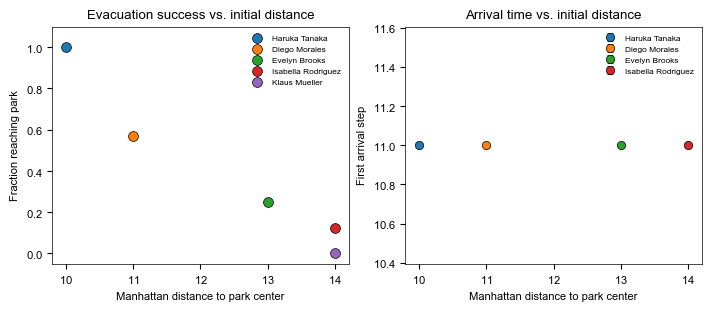

In [89]:
import numpy as np

park_center = (9 + 5/2, 9 + 5/2)  # Park region: x=9, y=9, w=5, h=5

agent_starts = {
    "Isabella Rodriguez": (23, 9),
    "Klaus Mueller":      (5, 19),
    "Haruka Tanaka":      (14, 4),
    "Diego Morales":      (22, 12),
    "Evelyn Brooks":      (3, 7),
}

evac_df["start_x"] = evac_df["agent"].map(lambda a: agent_starts.get(a, (None, None))[0])
evac_df["start_y"] = evac_df["agent"].map(lambda a: agent_starts.get(a, (None, None))[1])
evac_df["dist_to_park"] = evac_df.apply(
    lambda r: abs(r["start_x"] - park_center[0]) + abs(r["start_y"] - park_center[1])
    if r["start_x"] is not None else None, axis=1)

plt.rcParams.update({"font.family": "Arial", "font.size": 8,
                     "axes.formatter.use_mathtext": True,
                     "axes.linewidth": 0.5})

fig, axes = plt.subplots(1, 2, figsize=(7, 3), constrained_layout=True)

# --- Panel A: Park evacuation rate vs initial distance ---
ax = axes[0]
agent_stats = (evac_df.groupby("agent")
               .agg(dist=("dist_to_park", "first"),
                    park_rate=("reached_park", "mean"))
               .sort_values("dist"))
agent_colors = {a: plt.cm.tab10(i) for i, a in enumerate(agent_stats.index)}
for agent, row in agent_stats.iterrows():
    ax.scatter(row["dist"], row["park_rate"], s=50, color=agent_colors[agent],
               edgecolor="black", linewidth=0.5, zorder=3, label=agent)
ax.set_xlabel("Manhattan distance to park center")
ax.set_ylabel("Fraction reaching park")
ax.set_ylim(-0.05, 1.1)
ax.set_title("Evacuation success vs. initial distance")
ax.legend(fontsize=6, frameon=False, loc="best")

# --- Panel B: First arrival step vs initial distance ---
ax = axes[1]
park_only = evac_df[evac_df["reached_park"]].copy()
arr_stats = (park_only.groupby("agent")
             .agg(dist=("dist_to_park", "first"),
                  mean_step=("first_park_step", "mean"),
                  std_step=("first_park_step", "std"))
             .sort_values("dist"))
for agent, row in arr_stats.iterrows():
    ax.errorbar(row["dist"], row["mean_step"],
                yerr=row["std_step"] if not np.isnan(row["std_step"]) else 0,
                fmt="o", ms=6, color=agent_colors[agent],
                ecolor="black", elinewidth=0.5, capsize=2, capthick=0.5,
                markeredgecolor="black", markeredgewidth=0.5, label=agent)
ax.set_xlabel("Manhattan distance to park center")
ax.set_ylabel("First arrival step")
ax.set_title("Arrival time vs. initial distance")
ax.legend(fontsize=6, frameon=False, loc="best")

plt.savefig("sim_outputs/distance_vs_evacuation.png", dpi=800, bbox_inches="tight", transparent=True)
plt.show()